# Data Exploration — Indonesian Job Dataset (JobPath)

**Tujuan:** melihat *kenyataan* dataset `dataset/jobs.jsonl` apa adanya, sebelum kita menentukan bentuk database SQL (MySQL) & vector DB (Qdrant).

Notebook ini **hanya eksplorasi** — tidak ada cleaning permanen, tidak ada ingestion. Output-nya adalah *daftar temuan + implikasi desain* yang jadi dasar untuk 2 notebook berikutnya:
- `salary_ml.ipynb` — model regresi untuk mengisi gaji kosong (FR-8.01)
- `data_ingestion.ipynb` — masukkan data ke MySQL & Qdrant

**Roadmap:** 1) Muat data → 2) Struktur & tipe → 3) Kualitas data → 4) Kolom kategorikal → 5) Salary → 6) Job description → 7) Timestamp → 8) Kesimpulan.

## Bagian 1 — Muat data & lihat sekilas

Dataset formatnya `.jsonl` (*JSON Lines*): **satu baris = satu objek JSON = satu lowongan**. Berbeda dari file `.json` biasa yang satu dokumen utuh. Jadi kita baca baris per baris.

Kita muat ke `pandas.DataFrame` supaya gampang dianalisis (mirip tabel Excel di dalam Python).

In [1]:
import json
from pathlib import Path

import pandas as pd

# Biar teks panjang (job_description) tidak terpotong terlalu pendek saat ditampilkan
pd.set_option("display.max_colwidth", 120)

# Notebook ada di folder notebooks/, dataset ada di ../dataset/
DATA_PATH = Path("..") / "dataset" / "jobs.jsonl"

# Baca .jsonl baris per baris -> list of dict
records = []
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:                      # lewati baris kosong
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Jumlah lowongan (baris) : {df.shape[0]}")
print(f"Jumlah kolom            : {df.shape[1]}")
print(f"Nama kolom              : {list(df.columns)}")

Jumlah lowongan (baris) : 473
Jumlah kolom            : 7
Nama kolom              : ['job_title', 'company_name', 'location', 'work_type', 'salary', 'job_description', '_scrape_timestamp']


In [2]:
# Lihat 3 baris pertama untuk merasakan bentuk datanya
df.head(3)

,job_title,company_name,location,work_type,salary,job_description,_scrape_timestamp
0,Data Analyst,PT Matahari Department Store Tbk,"Karawaci, Banten",Full time,None,"Responsibilities:\nCollect, manage, and analyze large datasets related to store performance and operational efficien...",2025-11-24T11:33:16.277561
1,Data Analyst Intern,"PT Surya Semesta Internusa, Tbk","Jakarta Selatan, Jakarta Raya",Paruh waktu,None,Job Description\nSupport in conducting thorough analysis of datasets and data cleansing to ensure accuracy and quali...,2025-11-24T11:33:32.629908
2,Data Analyst Supervisor,PT Pangan Lestari,"Surabaya, Jawa Timur",Full time,None,Tugas dan Tanggung Jawab:\nMembuat dan mengembangkan dashboard sesuai kebutuhan analisis perusahaan.\nMelakukan peng...,2025-11-24T11:33:48.982129


In [3]:
# Lihat SATU lowongan utuh (termasuk job_description yang panjang)
sample = df.iloc[0]
for col in df.columns:
    print(f"--- {col} ---")
    print(sample[col])
    print()

--- job_title ---
Data Analyst

--- company_name ---
PT Matahari Department Store Tbk

--- location ---
Karawaci, Banten

--- work_type ---
Full time

--- salary ---
None

--- job_description ---
Responsibilities:
Collect, manage, and analyze large datasets related to store performance and operational efficiency.
Support ongoing business and improvement projects by providing data insights, reports, and dashboards.
Collaborate with cross-functional teams (Operations, Merchandising, and Finance) to ensure accuracy and consistency of business data.
Assist in identifying trends, issues, and opportunities based on data analysis to support decision-making.
Develop and improve data tracking systems or templates to increase reporting efficiency.
Requirements
:
Bachelor’s degree in Business, Statistics, Industrial Engineering, or a related field.
1–2 years of experience in data analysis, business operations, or project support.
Strong analytical and numerical skills with attention to detail.
Pr

## Bagian 2 — Struktur & tipe data

Semua kolom akan terbaca sebagai `object` (teks), karena sumbernya JSON. Perhatikan yang **seharusnya bukan teks**:
- `salary` → seharusnya **angka** (untuk filter range gaji, FR-3.02)
- `_scrape_timestamp` → seharusnya **datetime**

Ini catatan transformasi untuk tahap ingestion. Kita juga lihat **cardinality** (jumlah nilai unik) untuk membedakan kolom **kategorikal** (sedikit nilai unik → cocok jadi filter) vs **teks bebas** (banyak nilai unik → cocok untuk RAG).

In [4]:
# Tipe data tiap kolom + jumlah non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   job_title          473 non-null    str  
 1   company_name       473 non-null    str  
 2   location           473 non-null    str  
 3   work_type          473 non-null    str  
 4   salary             473 non-null    str  
 5   job_description    473 non-null    str  
 6   _scrape_timestamp  473 non-null    str  
dtypes: str(7)
memory usage: 874.8 KB


In [5]:
# Cardinality: berapa banyak nilai UNIK per kolom?
#  - sedikit unik  -> kandidat kolom kategorikal / filter (mis. work_type)
#  - banyak unik   -> teks bebas (job_description) atau identitas (company_name)
card = df.nunique().sort_values()
print(card)
print(f'\nTotal baris: {len(df)}')

work_type              4
location              93
salary                96
job_title            346
company_name         399
job_description      465
_scrape_timestamp    473
dtype: int64

Total baris: 473


## Bagian 3 — Kualitas data (diagnosa)

Di sini kita **hanya mendiagnosa**, belum memperbaiki (perbaikan → `data_ingestion.ipynb`). Tiga hal yang dicek:

1. **Missing asli** (`NaN`) — nilai yang benar-benar kosong menurut pandas.
2. **Missing tersembunyi** — kolom `salary` yang isinya string `"None"`. Ini *bukan* `NaN`, jadi lolos dari `isna()` dan mudah terlewat.
3. **Duplikat** — lowongan yang sama di-posting berkali-kali.

Plus satu catatan soal **encoding** yang tadi sempat bikin salah paham (mojibake = artefak baca file, bukan data rusak).

In [6]:
# 1. Missing "asli" (NaN) per kolom -> kemungkinan besar 0, karena kekosongan
#    disimpan sebagai string 'None', bukan null JSON.
df.isna().sum()

job_title            0
company_name         0
location             0
work_type            0
salary               0
job_description      0
_scrape_timestamp    0
dtype: int64

In [7]:
# 2. Missing "tersembunyi": nilai yang KELIHATAN terisi tapi sebenarnya kosong.
# Contoh paling penting: salary berisi string 'None' (bukan NaN, jadi lolos dari isna()).
placeholder = {'None', 'none', 'null', 'nan', '', '-'}

print('Nilai placeholder per kolom (dianggap kosong walau bukan NaN):')
for col in df.columns:
    s = df[col].astype(str).str.strip()
    n = s.isin(placeholder).sum()
    if n:
        print(f"  {col:20s}: {n:4d} ({n/len(df)*100:.1f}%)")

salary_kosong = df['salary'].astype(str).str.strip().isin(placeholder).sum()
print(f"\n=> salary kosong: {salary_kosong}/{len(df)} = {salary_kosong/len(df)*100:.1f}%")

Nilai placeholder per kolom (dianggap kosong walau bukan NaN):
  salary              :  293 (61.9%)

=> salary kosong: 293/473 = 61.9%


In [8]:
# 3. Duplikat
# a) baris identik 100% di semua kolom
full_dup = df.duplicated().sum()
print(f'Baris duplikat penuh (semua kolom sama): {full_dup}')

# b) lowongan "sama" berdasarkan judul + perusahaan + lokasi (indikasi re-post)
key_cols = ['job_title','job_description', 'company_name', 'location']
repost = df.duplicated(subset=key_cols).sum()
print(f'Duplikat berdasarkan {key_cols}: {repost}')

# Tampilkan contoh grup yang berulang, kalau ada
if repost:
    dupe_mask = df.duplicated(subset=key_cols, keep=False)
    print('\nContoh grup yang berulang:')
    display(df[dupe_mask].sort_values(key_cols)[key_cols + ['work_type', 'salary']].head(10))

Baris duplikat penuh (semua kolom sama): 0
Duplikat berdasarkan ['job_title', 'job_description', 'company_name', 'location']: 8

Contoh grup yang berulang:


,job_title,job_description,company_name,location,work_type,salary
317,Brand Manager,Job Description\nDevelop and execute\nbrand strategies\nthat directly support\nannual sales targets and market expan...,Orang Tua Group,"Jakarta Barat, Jakarta Raya",Full time,None
320,Brand Manager,Job Description\nDevelop and execute\nbrand strategies\nthat directly support\nannual sales targets and market expan...,Orang Tua Group,"Jakarta Barat, Jakarta Raya",Full time,None
0,Data Analyst,"Responsibilities:\nCollect, manage, and analyze large datasets related to store performance and operational efficien...",PT Matahari Department Store Tbk,"Karawaci, Banten",Full time,None
427,Data Analyst,"Responsibilities:\nCollect, manage, and analyze large datasets related to store performance and operational efficien...",PT Matahari Department Store Tbk,"Karawaci, Banten",Full time,None
240,Graphic Designer (DG - GDTRV - 110),"Graphic Designer (DG - GDTRV - 110)\n-\nNovember 24, 2025\nContract\nNegotiable\nApply Now\nWe are looking for a cre...",PT DECA,"Jakarta Utara, Jakarta Raya",Kontrak/Temporer,None
255,Graphic Designer (DG - GDTRV - 110),"Graphic Designer (DG - GDTRV - 110)\n-\nNovember 24, 2025\nContract\nNegotiable\nApply Now\nWe are looking for a cre...",PT DECA,"Jakarta Utara, Jakarta Raya",Kontrak/Temporer,None
150,HR Generalist Senior Staff (Industrial),"We are looking for an experienced HR Generalist who is dynamic, proactive, and ready to work in both South Jakarta a...",PT Lawencon Internasional,"Jakarta Selatan, Jakarta Raya",Full time,None
356,HR Generalist Senior Staff (Industrial),"We are looking for an experienced HR Generalist who is dynamic, proactive, and ready to work in both South Jakarta a...",PT Lawencon Internasional,"Jakarta Selatan, Jakarta Raya",Full time,None
381,Human Resources,"Job Overview\nThis is a full-time on-site role for a\nHuman Resource Associate\nlocated in\nKelapa Gading, North Jak...",Heura,"Kelapa Gading, Jakarta Raya",Full time,None
382,Human Resources,"Job Overview\nThis is a full-time on-site role for a\nHuman Resource Associate\nlocated in\nKelapa Gading, North Jak...",Heura,"Kelapa Gading, Jakarta Raya",Full time,None


In [9]:
# Catatan encoding: dataset ini SEBENARNYA UTF-8 yang bersih.
# 'Mojibake' (mis. 'Bachelorâ€™s') hanya muncul kalau file dibaca TANPA encoding='utf-8'
# (di Windows, default open() = cp1252). Kita selalu pakai encoding='utf-8' -> aman.
markers = ['â€', 'Ã©', 'Ã¢']
blob = df.astype(str).apply(lambda r: ' '.join(r), axis=1)
n_mojibake = blob.str.contains('|'.join(markers), regex=True).sum()
print(f'Baris dengan pola mojibake (harusnya 0): {n_mojibake}')

Baris dengan pola mojibake (harusnya 0): 0


## Bagian 4 — Kolom kategorikal & identitas

Dari cardinality tadi, 4 kolom ini kita bagi perannya:

| Kolom | Unik | Peran |
|---|---|---|
| `work_type` | 4 | **Filter** Smart Search (FR-3.03) — perlu normalisasi ID/EN |
| `location` | 93 | **Filter** lokasi (FR-3.04) — pecah kota/provinsi + tangkap Remote/Hybrid |
| `job_title` | 346 | Teks semi-bebas → dasar Career Path & Skill Gap (FR-5) |
| `company_name` | 399 | Hampir unik → untuk tampilan, bukan filter |

Mulai sini kita pakai **grafik** biar distribusinya kelihatan.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 12

### 4.1 `work_type` — tipe pekerjaan (kandidat filter)

Cuma 4 nilai unik, tapi **campur bahasa** (Indonesia + Inggris). Untuk filter yang rapi di Smart Search (FR-3.03), nanti perlu dipetakan ke label standar, mis. `Kontrak/Temporer` → `Contract`, `Paruh waktu` → `Part time`.

work_type
Full time           407
Kontrak/Temporer     62
Paruh waktu           2
Kasual                2
Name: count, dtype: int64


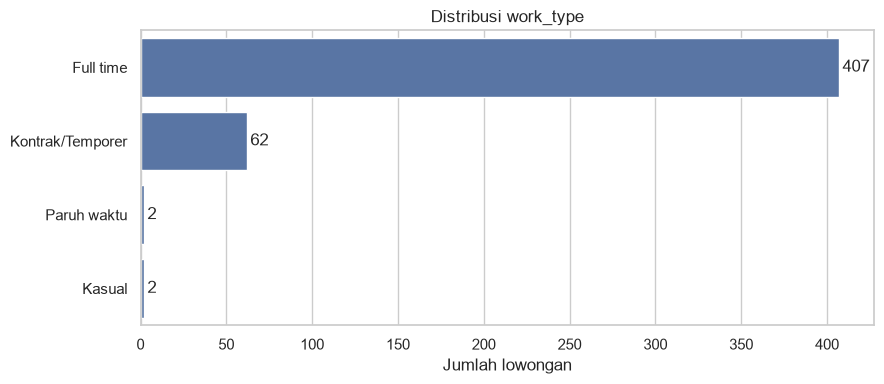

In [11]:
vc = df['work_type'].value_counts(dropna=False)
print(vc)

ax = sns.barplot(x=vc.values, y=vc.index, color='#4C72B0')
ax.set_title('Distribusi work_type'); ax.set_xlabel('Jumlah lowongan'); ax.set_ylabel('')
for i, v in enumerate(vc.values):
    ax.text(v + 2, i, str(v), va='center')
plt.tight_layout(); plt.show()

### 4.2 `location` — lokasi kerja

Formatnya `"Kota, Provinsi"`. Dua hal yang perlu didiagnosa:
1. Sebagian menyisipkan penanda **Remote/Hybrid** di dalam string (mis. `"...\n(Hibrid)"`). Ini penting karena `work_type` **tidak** memiliki kategori Remote/Hybrid — sehingga informasi tersebut tersembunyi di kolom ini.
2. Untuk filter yang berguna (FR-3.04), `location` sebaiknya dipecah menjadi **kota** dan **provinsi**.

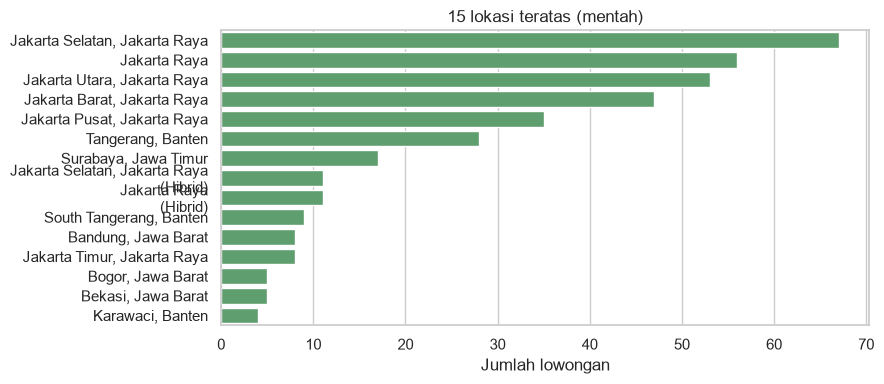

In [12]:
top_loc = df['location'].value_counts().head(15)
ax = sns.barplot(x=top_loc.values, y=top_loc.index, color='#55A868')
ax.set_title('15 lokasi teratas (mentah)')
ax.set_xlabel('Jumlah lowongan'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [13]:
# Diagnosa penanda Remote/Hybrid yang tersembunyi di dalam location
mask = df['location'].str.contains('hibrid|hybrid|remote|jarak jauh', case=False, regex=True)
print(f'location dengan penanda Remote/Hybrid: {mask.sum()}')
for v in df.loc[mask, 'location'].unique()[:8]:
    print('  ', repr(v))

# "Provinsi" ~ potongan setelah koma terakhir, setelah membuang teks dalam kurung & newline
prov = (df['location']
        .str.replace(r'\(.*?\)', '', regex=True)
        .str.replace('\n', ' ', regex=True)
        .str.split(',').str[-1].str.strip())
print('\nPerkiraan distribusi provinsi (top 10):')
print(prov.value_counts().head(10))

location dengan penanda Remote/Hybrid: 41
   'Jakarta Selatan, Jakarta Raya\n(Hibrid)'
   'Jakarta Barat, Jakarta Raya\n(Hibrid)'
   'Jakarta Raya\n(Jarak jauh)'
   'Cilandak, Jakarta Raya\n(Hibrid)'
   'Makassar, Sulawesi Selatan\n(Hibrid)'
   'Jakarta Raya\n(Hibrid)'
   'Jakarta Pusat, Jakarta Raya\n(Hibrid)'
   'Bali\n(Jarak jauh)'

Perkiraan distribusi provinsi (top 10):
location
Jakarta Raya        316
Banten               56
Jawa Barat           42
Jawa Timur           27
Bali                 11
Jawa Tengah           5
Sumatera Utara        4
Kepulauan Riau        4
Sulawesi Selatan      1
Sumatera Selatan      1
Name: count, dtype: int64


#### 4.2b Penanda Remote/Hybrid dari `job_description`

Penanda Remote/Hybrid tidak hanya di `location`; sering ditulis di `job_description`. Bagian ini memeriksa `job_description` untuk menangkap yang terlewat, lalu membandingkan berapa **tambahan** yang hanya ditemukan di JD. Perlu diwaspadai **false positive** — kata *remote* pada JD teknis kadang bermakna lain (mis. *remote server*), sehingga cuplikan kalimat pemicu ditampilkan untuk penilaian manual.

In [14]:
# Tangkap penanda Remote/Hybrid dari job_description (bukan hanya dari location).
loc_flag = df['location'].str.contains('hibrid|hybrid|remote|jarak jauh', case=False, regex=True)

jd = df['job_description'].fillna('')
jd_remote = jd.str.contains(r'\bremote\b|work from home|\bwfh\b|kerja dari rumah|jarak jauh', case=False, regex=True)
jd_hybrid = jd.str.contains(r'hybrid|hibrid', case=False, regex=True)
jd_flag = jd_remote | jd_hybrid

print(f'Penanda dari location       : {loc_flag.sum()}')
print(f'Penanda dari job_description : {jd_flag.sum()}  (remote={jd_remote.sum()}, hybrid={jd_hybrid.sum()})')
print(f'Gabungan (location OR JD)    : {(loc_flag | jd_flag).sum()}')
print(f'  - hanya ditemukan di JD (tambahan): {(jd_flag & ~loc_flag).sum()}')

# Cuplikan kalimat pemicu untuk menilai false positive ('remote server' dll)
import re
pat = re.compile(r'.{0,35}(remote|work from home|wfh|hybrid|hibrid|jarak jauh).{0,35}', re.I)
print('\nContoh cuplikan (yang hanya ditemukan di JD):')
shown = 0
for text in df.loc[jd_flag & ~loc_flag, 'job_description']:
    m = pat.search(text)
    if m:
        print('  ...', m.group(0).replace('\n', ' ').strip(), '...')
        shown += 1
    if shown >= 6:
        break

Penanda dari location       : 41
Penanda dari job_description : 23  (remote=13, hybrid=13)
Gabungan (location OR JD)    : 45
  - hanya ditemukan di JD (tambahan): 4

Contoh cuplikan (yang hanya ditemukan di JD):
  ... Machine Learning Staff *Remote Work. ...
  ... ce through flexible scheduling and remote work options. If you're ready to j ...
  ... join our dynamic team. This unique hybrid role combines three key pillars: C ...
  ... Hybrid ...


### 4.3 `job_title` — judul pekerjaan

346 unik dari 473 → **semi-bebas**. Untuk Career Path & Skill Gap (FR-5) kita butuh sinyal **senioritas** (Intern/Junior/Senior/Lead/Manager). Kita lihat judul terpopuler + scan kata kunci senioritas.

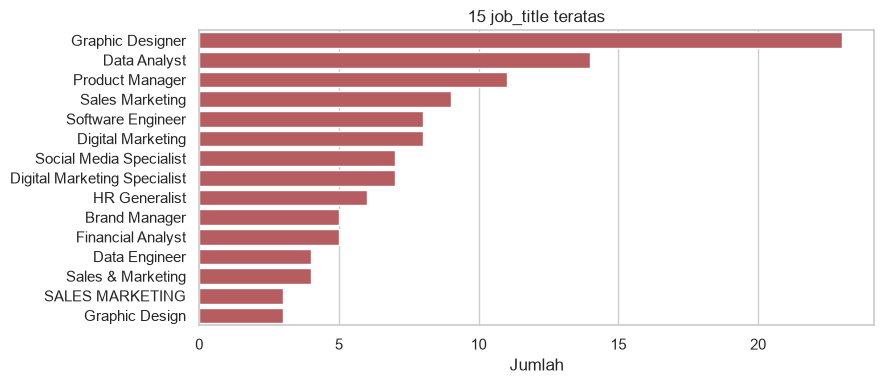

Kemunculan kata kunci senioritas di job_title:
  intern      : 1
  junior      : 3
  senior      : 24
  lead        : 5
  manager     : 81
  supervisor  : 17
  head        : 5
  staff       : 40

Total kemunculan kata kunci senioritas: 176


In [15]:
# Judul terpopuler
top_titles = df['job_title'].value_counts().head(15)
ax = sns.barplot(x=top_titles.values, y=top_titles.index, color='#C44E52')
ax.set_title('15 job_title teratas'); ax.set_xlabel('Jumlah'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

# Sinyal senioritas dari judul (berguna untuk Career Path / Skill Gap, FR-5)
levels = ['intern', 'junior', 'senior', 'lead', 'principal', 'manager', 'supervisor', 'head', 'staff']
low = df['job_title'].str.lower()
print('Kemunculan kata kunci senioritas di job_title:')
sum = 0
for lv in levels:
    n = low.str.contains(lv).sum()
    if n:
        print(f'  {lv:12s}: {n}')
        sum += n
print(f'\nTotal kemunculan kata kunci senioritas: {sum}')


#### 4.3b Senioritas: `job_title` vs `job_description`

Sinyal senioritas di judul hanya menutup sebagian lowongan; sisanya berjudul "polos" (mis. hanya *Data Analyst*). Perlu diperiksa apakah senioritasnya tersirat di `job_description` lewat dua sinyal: (a) kata level (senior/junior/…) dan (b) **tahun pengalaman** (*3 years* / *5 tahun*) — proxy senioritas yang paling kuat.

In [16]:
import re

levels = ['intern', 'junior', 'senior', 'lead', 'principal', 'manager', 'supervisor', 'head', 'staff']
pat_lvl = '|'.join(levels)

# Berapa lowongan yang JUDUL-nya sudah bersinyal senioritas vs "polos"?
title_has = df['job_title'].str.contains(pat_lvl, case=False, regex=True)
print(f"Judul dengan sinyal senioritas : {title_has.sum()} ({title_has.mean()*100:.1f}%)")
print(f"Judul 'polos' (tanpa sinyal)    : {(~title_has).sum()}")

# Untuk yang polos: apakah sinyalnya ada di job_description?
jd = df['job_description'].fillna('')
jd_has_lvl = jd.str.contains(pat_lvl, case=False, regex=True)

# Sinyal kuat lain: tahun pengalaman (mis. '3 years', '5+ tahun')
jd_years = jd.str.extract(r'(\d+)\s*\+?\s*(?:years?|tahun|thn)', flags=re.I)[0].astype('float')
has_years = jd_years.notna()

polos = ~title_has
print(f"\nDari {polos.sum()} judul polos, sinyal di job_description:")
print(f"  - ada kata level (senior/junior/...): {(polos & jd_has_lvl).sum()}")
print(f"  - ada 'tahun pengalaman'            : {(polos & has_years).sum()}")
print(f"  - tetap tanpa sinyal apa pun        : {(polos & ~jd_has_lvl & ~has_years).sum()}")

print("\nDistribusi 'tahun pengalaman' yang disebut di JD (proxy senioritas):")
print(jd_years.dropna().astype(int).value_counts().sort_index().head(12))

Judul dengan sinyal senioritas : 165 (34.9%)
Judul 'polos' (tanpa sinyal)    : 308

Dari 308 judul polos, sinyal di job_description:
  - ada kata level (senior/junior/...): 167
  - ada 'tahun pengalaman'            : 234
  - tetap tanpa sinyal apa pun        : 39

Distribusi 'tahun pengalaman' yang disebut di JD (proxy senioritas):
0
1     57
2     94
3     83
4     20
5     75
6      4
7      5
8      6
10    12
12     2
13     1
15     1
Name: count, dtype: int64


Ke-39 lowongan tanpa sinyal senioritas ditampilkan di bawah untuk telaah manual (judul, perusahaan, dan cuplikan awal `job_description`). Kolom `row` adalah indeks baris asli agar mudah ditelusuri kembali.

In [17]:
# Daftar lowongan tanpa sinyal senioritas di mana pun (untuk telaah manual)
no_signal = ~title_has & ~jd_has_lvl & jd_years.isna()
print(f'Jumlah tanpa sinyal senioritas: {no_signal.sum()}')

review = df.loc[no_signal, ['job_title', 'company_name']].copy()
review['jd_awal'] = (df.loc[no_signal, 'job_description']
                     .str.replace(r'\s+', ' ', regex=True)
                     .str[:100])
review.reset_index(names='row')

Jumlah tanpa sinyal senioritas: 39


,row,job_title,company_name,jd_awal
0,3,Data Analyst,PT 8 ELEMENTS,"Job Description Data Analysis and Interpretation: Utilize tools like Google Data Studio, BigQuery, a"
1,4,Data Analyst,PT Quadra Inti Solusi,"Kualifikasi: Pendidikan minimal S1 Statistik, Matematika, Teknologi Informasi, atau jurusan terkait."
2,9,Data Analyst,PT ACCENTUATES,"KUALIFIKASI : - Pendidikan minimal S1 jurusan Matematika, Statistika, Ilmu Komputer,"
3,34,Soil Health Officer,PT Timbang Deli Indonesia,"About Verdant : Verdant is a plantation science company in North Sumatra driving sustainable, high-y"
4,42,Data Analyst,"PT. BFI FINANCE INDONESIA, Tbk","Job Description Mengelola, mengolah, menganalisa dan menginterpretasikan data seperti scoring branch"
5,50,Branch Operation Analyst,"PT. BFI FINANCE INDONESIA, Tbk","Job Description Mengelola, mengolah, menganalisa dan menginterpretasikan data seperti scoring branch"
6,51,Admin Data Analyst,PT Global Yimi Cargo (J&T Cargo),Tugas & Tanggung Jawab: Merancang dan memelihara sistem data serta database perusahaan. Mengidentifi
7,53,Data Analyst,Pengiklan Anonim,"Tugas dan tanggung jawab: Mengumpulkan dan mengelola data : Mengumpulkan data dari berbagai sumber,"
8,65,SALES MARKETING,PT Servanda Ventura Swareksa,SALES MARKETING ü S1 Segala Jurusan ü Berpengalaman menjual program Training / Pelatihan ü Terbia
9,69,Sales & Marketing,CV GUNUNG MAS SEJATI,"Kualifikasi: Pendidikan minimal SMA/SMK, D3 atau S1 (lebih disukai bidang Marketing, Bisnis, atau se"


### 4.4 `company_name` — perusahaan

399 unik dari 473 → hampir semua beda. Perannya untuk **tampilan** hasil pencarian, bukan filter. Kita lihat perusahaan yang paling banyak posting (indikasi sedang aktif merekrut).

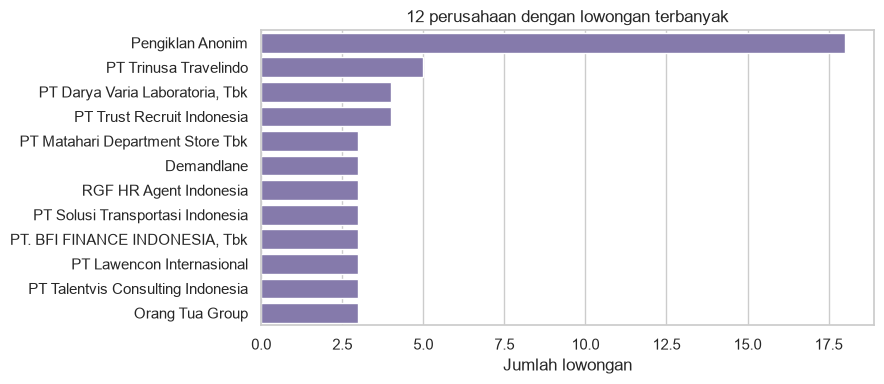

In [18]:
top_co = df['company_name'].value_counts().head(12)
ax = sns.barplot(x=top_co.values, y=top_co.index, color='#8172B3')
ax.set_title('12 perusahaan dengan lowongan terbanyak')
ax.set_xlabel('Jumlah lowongan'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [19]:
# Kualitas: perusahaan teratas ternyata placeholder "Pengiklan anonim"
# -> ini "missing tersembunyi" untuk company_name (identitas disembunyikan).
anon = df['company_name'].str.contains('anonim|anonymous|confidential|rahasia', case=False, regex=True)
print(f'Lowongan tanpa nama perusahaan jelas: {anon.sum()} ({anon.sum()/len(df)*100:.1f}%)')
print(df.loc[anon, 'company_name'].value_counts().head())

Lowongan tanpa nama perusahaan jelas: 18 (3.8%)
company_name
Pengiklan Anonim    18
Name: count, dtype: int64


## Bagian 5 — `salary`

Kolom paling berantakan sekaligus paling penting: untuk filter gaji (FR-3.02) dan sebagai target `salary_ml.ipynb` (FR-8.01).

Kondisi: ~62% berisi `"None"`; sisanya beragam bentuk:
- **Tunggal**: `"Rp 10.000.000 per month"`
- **Range**: `"Rp 6.000.000 – Rp 7.000.000 per month"`
- **Non-angka**: `"World Class Benefits"` (harus dianggap kosong)

Langkah: klasifikasikan pola, lalu ekstrak `salary_min`/`salary_max`/`period` **hanya untuk melihat distribusi** — bukan disimpan; transformasi final dilakukan di ingestion.

In [20]:
# Lihat variasi nilai salary yang terisi
placeholder = {'none', 'null', 'nan', '', '-'}
is_filled = ~df['salary'].astype(str).str.strip().str.lower().isin(placeholder)
filled = df.loc[is_filled, 'salary']
print(f'Salary terisi: {is_filled.sum()} dari {len(df)} ({is_filled.mean() * 100:.1f}%)')
print('\nContoh acak:')
for v in filled.sample(15, random_state=0):
    print('  ', repr(v))

Salary terisi: 180 dari 473 (38.1%)

Contoh acak:
   'Rp\xa03.750.000 – Rp\xa05.500.000 per month'
   'Rp\xa012.000.000 – Rp\xa018.000.000 per month'
   'Rp\xa013.000.000 – Rp\xa018.000.000 per month'
   'Rp\xa07.000.000 – Rp\xa09.000.000 per month'
   'Rp\xa010.000.000 – Rp\xa015.000.000 per month'
   'Rp\xa07,000,000 – Rp\xa09,000,000 per month'
   'Rp\xa07.500.000 – Rp\xa010.000.000 per month'
   'Rp\xa013.500.000 – Rp\xa020.000.000 per month'
   'Rp\xa04.500.000 – Rp\xa06.000.000 per month'
   'Rp\xa06.000.000 – Rp\xa07.000.000 per month'
   'Rp\xa010.000.000 – Rp\xa015.000.000 per month'
   'Rp\xa05.000.000 – Rp\xa06.500.000 per month'
   'Rp\xa04.900.000 – Rp\xa05.000.000 per month'
   'Rp\xa04.500.000 – Rp\xa05.000.000 per month'
   'Rp\xa05.000.000 – Rp\xa07.000.000 per month'


In [21]:
import re

def parse_salary(s):
    """Klasifikasi & ekstraksi kasar nilai salary untuk diagnosa distribusi.

    Heuristik: buang pemisah ribuan (titik ATAU koma), ambil angka >= 4 digit.
    2 angka -> range, 1 angka -> tunggal, 0 angka -> non-angka.
    """
    t = str(s).strip()
    if t.lower() in {'none', 'null', 'nan', '', '-'}:
        return pd.Series({'kategori': 'kosong', 'salary_min': None, 'salary_max': None, 'period': None})
    low = t.lower()
    if 'month' in low or 'bulan' in low:
        period = 'month'
    elif 'year' in low or 'annum' in low or 'tahun' in low:
        period = 'year'
    elif 'hour' in low or 'jam' in low:
        period = 'hour'
    else:
        period = None
    # Dataset memakai titik DAN koma sebagai pemisah ribuan -> buang keduanya
    cleaned = t.replace('\xa0', ' ').replace('.', '').replace(',', '')
    nums = [int(n) for n in re.findall(r'\d+', cleaned) if len(n) >= 4]
    if len(nums) >= 2:
        return pd.Series({'kategori': 'range', 'salary_min': min(nums[:2]), 'salary_max': max(nums[:2]), 'period': period})
    if len(nums) == 1:
        return pd.Series({'kategori': 'tunggal', 'salary_min': nums[0], 'salary_max': nums[0], 'period': period})
    return pd.Series({'kategori': 'non-angka', 'salary_min': None, 'salary_max': None, 'period': period})

parsed = df['salary'].apply(parse_salary)
print('Kategori pola salary:')
print(parsed['kategori'].value_counts())
print('\nPeriod:')
print(parsed['period'].value_counts(dropna=False))

Kategori pola salary:
kategori
kosong       293
range        176
tunggal        2
non-angka      2
Name: count, dtype: int64

Period:
period
NaN      295
month    178
Name: count, dtype: int64


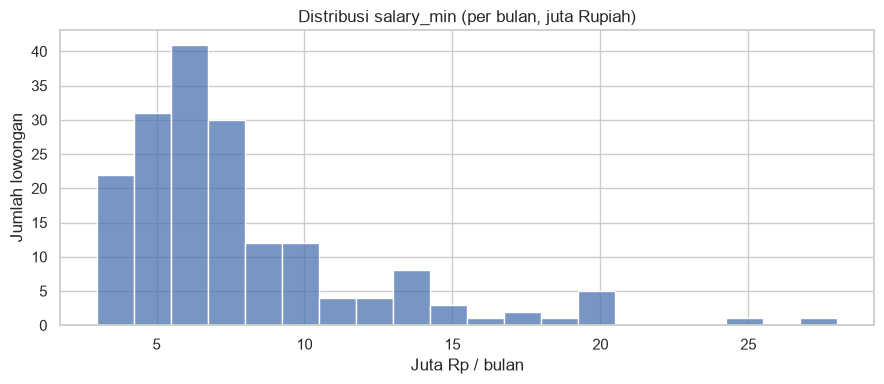

Lowongan dengan gaji per bulan terparse: 178
count    178.00
mean       7.75
std        4.21
min        3.00
25%        5.00
50%        6.50
75%        9.00
max       28.00
Name: salary_min, dtype: float64


In [22]:
# Distribusi salary_min untuk yang periodenya per bulan (satuan juta Rupiah)
mask_num = parsed['salary_min'].notna() & (parsed['period'] == 'month')
vals = parsed.loc[mask_num, 'salary_min'].astype(float) / 1_000_000

ax = sns.histplot(vals, bins=20, color='#4C72B0')
ax.set_title('Distribusi salary_min (per bulan, juta Rupiah)')
ax.set_xlabel('Juta Rp / bulan'); ax.set_ylabel('Jumlah lowongan')
plt.tight_layout(); plt.show()

print(f'Lowongan dengan gaji per bulan terparse: {mask_num.sum()}')
print(vals.describe().round(2))

In [23]:
# Nilai "non-angka" -> di ingestion nanti diperlakukan sebagai kosong
print('Contoh salary non-angka:')
print(df.loc[parsed['kategori'] == 'non-angka', 'salary'].value_counts().head(10))

Contoh salary non-angka:
salary
World Class Benefits         1
Competitive Reimuneration    1
Name: count, dtype: int64


## Bagian 6 — `job_description` (panjang teks → keputusan chunking)

`job_description` adalah sumber utama dokumen RAG yang di-embed ke Qdrant. Panjang teks menentukan perlu-tidaknya **chunking**: `text-embedding-3-small` menampung ~8191 token per input. Jika mayoritas teks pendek, cukup **1 vector per lowongan** (lebih sederhana, metadata rapi).

In [24]:
jd = df['job_description'].fillna('')
char_len = jd.str.len()
word_len = jd.str.split().apply(len)
approx_tokens = (char_len / 4).round().astype(int)  # perkiraan kasar: ~4 karakter per token

print('Panjang karakter:'); print(char_len.describe().round(0))
print('\nJumlah kata:'); print(word_len.describe().round(0))
print('\nPerkiraan token (char/4):'); print(approx_tokens.describe().round(0))
print(f'\nMax perkiraan token : {approx_tokens.max()}  (batas embedding-3-small: 8191)')
print(f'JD dengan perkiraan token > 8191 : {(approx_tokens > 8191).sum()}')

Panjang karakter:
count     473.0
mean     1703.0
std      1061.0
min       184.0
25%      1013.0
50%      1494.0
75%      2141.0
max      9407.0
Name: job_description, dtype: float64

Jumlah kata:
count     473.0
mean      230.0
std       147.0
min        25.0
25%       136.0
50%       198.0
75%       287.0
max      1364.0
Name: job_description, dtype: float64

Perkiraan token (char/4):
count     473.0
mean      426.0
std       265.0
min        46.0
25%       253.0
50%       374.0
75%       535.0
max      2352.0
Name: job_description, dtype: float64

Max perkiraan token : 2352  (batas embedding-3-small: 8191)
JD dengan perkiraan token > 8191 : 0


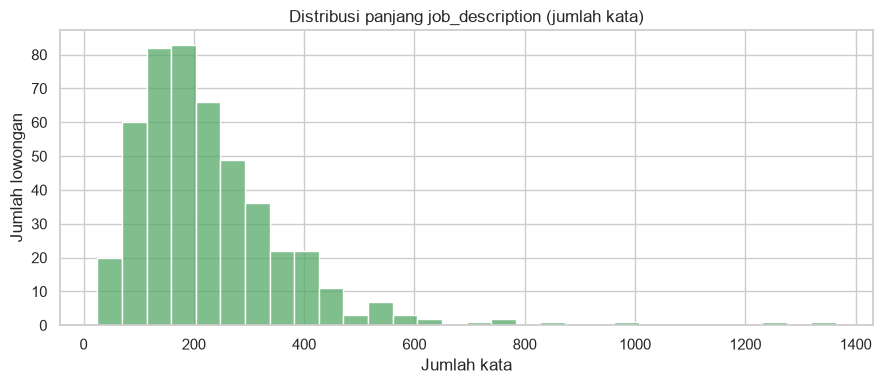

In [25]:
ax = sns.histplot(word_len, bins=30, color='#55A868')
ax.set_title('Distribusi panjang job_description (jumlah kata)')
ax.set_xlabel('Jumlah kata'); ax.set_ylabel('Jumlah lowongan')
plt.tight_layout(); plt.show()

In [26]:
# Struktur & bahasa (heuristik kasar)
low = jd.str.lower()
print('Kandungan penanda struktur:')
for kw in ['requirement', 'responsibilit', 'kualifikasi', 'tugas', 'tanggung jawab', 'benefit']:
    print(f'  {kw:16s}: {low.str.contains(kw).sum()}')

id_sig = low.str.contains(r'\b(?:dan|yang|untuk|dengan|perusahaan)\b', regex=True)
en_sig = low.str.contains(r'\b(?:and|the|with|experience|responsibilities)\b', regex=True)
print(f'\nJD mengandung kata Indonesia : {id_sig.sum()}')
print(f'JD mengandung kata Inggris   : {en_sig.sum()}')
print(f'JD mengandung keduanya        : {(id_sig & en_sig).sum()}')

Kandungan penanda struktur:
  requirement     : 168
  responsibilit   : 145
  kualifikasi     : 139
  tugas           : 45
  tanggung jawab  : 107
  benefit         : 69

JD mengandung kata Indonesia : 190
JD mengandung kata Inggris   : 307
JD mengandung keduanya        : 25


## Bagian 7 — `_scrape_timestamp`

Waktu pengambilan data. Berguna sebagai penanda kebaruan/urutan, dan kandidat kolom `created_at` di MySQL.

In [27]:
ts = pd.to_datetime(df['_scrape_timestamp'])
print(f'Rentang waktu scraping : {ts.min()}  ->  {ts.max()}')
print(f'Durasi                 : {ts.max() - ts.min()}')
print(f'Jumlah tanggal unik    : {ts.dt.date.nunique()}')
print('\nJumlah lowongan per tanggal:')
print(ts.dt.date.value_counts().sort_index())

Rentang waktu scraping : 2025-11-24 11:33:16.277561  ->  2025-11-24 13:01:59.470006
Durasi                 : 0 days 01:28:43.192445
Jumlah tanggal unik    : 1

Jumlah lowongan per tanggal:
_scrape_timestamp
2025-11-24    473
Name: count, dtype: int64


## Bagian 8 — Kesimpulan & implikasi desain database

### Ringkasan temuan

| Kolom | Temuan utama | Implikasi |
|---|---|---|
| — | 473 baris, 7 kolom, **0 NaN**, **0 mojibake** (baca UTF-8) | data kecil & relatif bersih |
| duplikat | **8 baris** identik (judul+deskripsi+perusahaan+lokasi) | **drop** saat ingestion → 465 baris unik |
| `salary` | **62% kosong** (`"None"`); sisanya **176 range + 2 tunggal = 178 numerik**, 2 benar-benar non-angka; semua per bulan; Rp 3–28 jt (median 6,5 jt) | pisah `salary_min/max`; pemisah ribuan bisa **titik ATAU koma**; 178 baris jadi data latih `salary_ml` |
| `work_type` | 4 nilai, campur ID/EN (Full time 407, Kontrak 62, Paruh waktu 2, Kasual 2) | normalisasi ke label standar |
| `location` | format `"Kota, Provinsi"`; **41** menyimpan penanda Remote/Hybrid (+4 dari JD = 45) | pecah `city`/`province` + kolom `work_arrangement` |
| `job_title` | 346 unik; senioritas: 165 dari judul, sisanya dari JD; **hanya 39 (8%) tanpa sinyal** | `seniority_level` bisa diturunkan (best-effort) |
| `company_name` | 399 unik; **18 (3,8%) "Pengiklan Anonim"** | perlakukan anonim sebagai kosong/unknown |
| `job_description` | ~230 kata (maks 1364); **perkiraan token maks 2352 < 8191**, tak ada yang melebihi batas; bilingual ID/EN | **tanpa chunking** → 1 vector per lowongan |
| `_scrape_timestamp` | semuanya **24 Nov 2025** dalam ~1,5 jam (1 batch) | nilai analitik rendah; sekadar `created_at` |

### Rancangan MySQL — tabel tunggal `jobs`

| Kolom | Tipe | Asal / transformasi |
|---|---|---|
| `job_id` | PK (di-generate) | tidak ada ID alami; generate setelah dedup |
| `job_title` | VARCHAR | apa adanya |
| `company_name` | VARCHAR NULL | `"Pengiklan Anonim"` → NULL |
| `city`, `province` | VARCHAR | pecah dari `location` |
| `work_type` | VARCHAR | normalisasi ID/EN |
| `work_arrangement` | ENUM(Onsite/Hybrid/Remote) | dari penanda `location` (+JD) |
| `seniority_level` | VARCHAR NULL | turunan judul + JD (best-effort) |
| `salary_min`, `salary_max` | INT NULL | parse; NULL bila kosong/non-angka |
| `salary_period` | VARCHAR | saat ini seragam `month` |
| `is_salary_estimated` | BOOL | `TRUE` bila diisi model `salary_ml` |
| `job_description` | TEXT | apa adanya (sumber RAG) |
| `created_at` | DATETIME | dari `_scrape_timestamp` |

### Rancangan Qdrant — collection `jobs`

- **1 vector per lowongan** (tanpa chunking — teks terpanjang ~2352 token, jauh di bawah 8191).
- **Teks yang di-embed**: gabungan `job_title` + `company_name` + `work_type` + `location` + `job_description`.
- **Model**: OpenAI `text-embedding-3-small` (1536 dim, cosine). Dataset bilingual → model multilingual cocok.
- **Payload**: `job_id` (jembatan ke MySQL) + metadata filter (`city`, `province`, `work_type`, `work_arrangement`, `seniority_level`, `salary_min`, `salary_max`) untuk **hybrid search**.

### Diteruskan ke notebook berikutnya

- **`salary_ml.ipynb`**: target = 178 gaji numerik; fitur kandidat = `job_title`/senioritas, `city`/`province`, `work_type`, panjang `job_description`.
- **`data_ingestion.ipynb`** (daftar cleaning): dedup 8 baris · normalisasi `work_type` · pecah `location` + `work_arrangement` · parse `salary` (titik & koma) · `company_name` anonim → NULL · turunkan `seniority_level` · generate `job_id`.